### STUDENT HEALTH ANALYSIS PROJECT

In [105]:
## General Purpose
import warnings
from itertools import combinations
from copy import deepcopy

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
pd.set_option("display.max_columns", None)

In [106]:
df = pd.read_csv("data/test.csv")
df

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295748,985836,7.13,77.5,22.20,2221.0,13981.0,65.6,2.17,balanced,low,average,active,occasional,other
295749,985837,6.25,69.5,20.93,2242.0,2370.0,23.6,1.98,balanced,NaN,average,moderate,yes,female
295750,985838,NaN,77.0,23.62,2111.0,7647.0,25.1,2.18,veg,high,average,sedentary,no,other
295751,985839,7.25,66.3,21.47,2009.0,4672.0,25.1,2.02,veg,high,poor,moderate,no,female


In [107]:
student_data = df.drop('id', axis=1).copy()
student_data.head(5)

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other


In [108]:
student_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 295753 entries, 0 to 295752
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   sleep_duration           263182 non-null  float64
 1   heart_rate               292396 non-null  float64
 2   bmi                      289797 non-null  float64
 3   calorie_expenditure      273101 non-null  float64
 4   step_count               289789 non-null  float64
 5   exercise_duration        292795 non-null  float64
 6   water_intake             277120 non-null  float64
 7   diet_type                292795 non-null  str    
 8   stress_level             260263 non-null  str    
 9   sleep_quality            270754 non-null  str    
 10  physical_activity_level  280058 non-null  str    
 11  smoking_alcohol          283504 non-null  str    
 12  gender                   286593 non-null  str    
dtypes: float64(7), str(6)
memory usage: 29.3 MB


In [109]:
student_data.shape

(295753, 13)

In [110]:
student_data.isna().sum() / len(student_data) * 100

sleep_duration             11.012906
heart_rate                  1.135069
bmi                         2.013843
calorie_expenditure         7.659094
step_count                  2.016548
exercise_duration           1.000159
water_intake                6.300190
diet_type                   1.000159
stress_level               11.999878
sleep_quality               8.452662
physical_activity_level     5.306793
smoking_alcohol             4.141632
gender                      3.097179
dtype: float64

In [111]:
student_data['sleep_duration'] = student_data['sleep_duration'].interpolate()

In [112]:
most_frequent_value = student_data['stress_level'].mode()[0]
student_data['stress_level'] = student_data['stress_level'].fillna(most_frequent_value)

In [113]:
student_data['stress_level']

0           high
1           high
2         medium
3            low
4           high
           ...  
295748       low
295749    medium
295750      high
295751      high
295752      high
Name: stress_level, Length: 295753, dtype: str

In [114]:
student_data = student_data.dropna()
student_data.shape

(210865, 13)

In [115]:
student_data.isna().sum() / len(student_data) * 100

sleep_duration             0.0
heart_rate                 0.0
bmi                        0.0
calorie_expenditure        0.0
step_count                 0.0
exercise_duration          0.0
water_intake               0.0
diet_type                  0.0
stress_level               0.0
sleep_quality              0.0
physical_activity_level    0.0
smoking_alcohol            0.0
gender                     0.0
dtype: float64

##### Setting up outlier detection and cleaning 

In [116]:
# from pprint import pprint

# for col in student_data.select_dtypes(exclude=str):
#     mean = student_data[col].mean()
#     st_dev = student_data[col].std()
    
#     # Store clean floats in your dictionary
#     new_col[col] = float(mean), float(deviation)
    
#     ### Outlier definition
#     outlier_threasold =  st_dev * 3
#     print(f'--- {col} outlier ---')
#     print(outlier_threasold)
    
    
#     upper_limit = mean + outlier_threasold
#     lower_limit = mean - outlier_threasold
    
#     ## Getting outlier
#     outlier_numbers = (student_data[col] < lower_limit) | (student_data[col] > upper_limit)
#     print(f'Number of outliers found {outlier_numbers.sum()}\n')
    
# pprint(new_col)    
    

### Visualizing the outliers

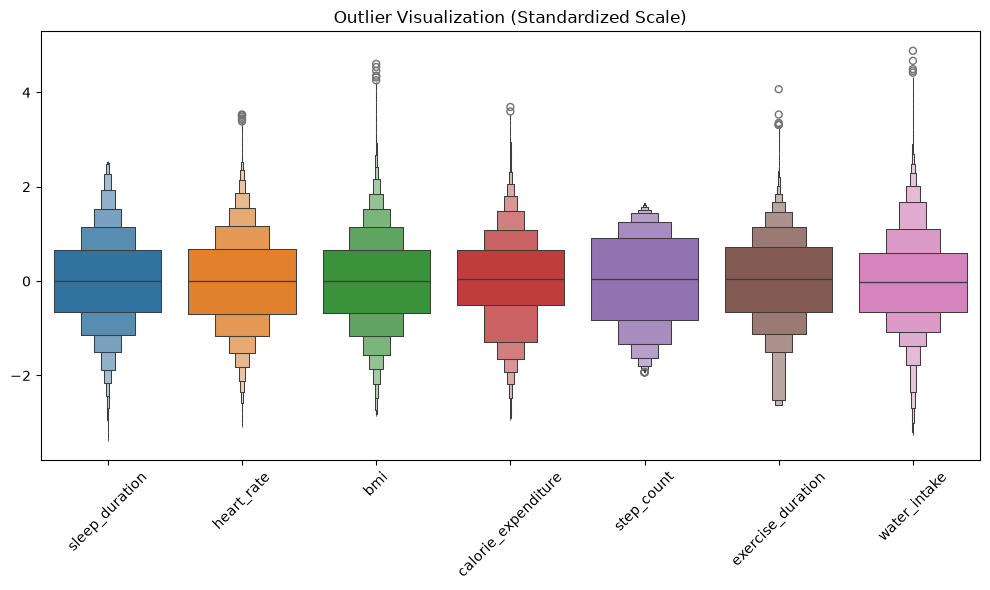

In [117]:
## Creating the boxplot
num_data = student_data.select_dtypes(exclude=str)

standardized_data = (num_data - num_data.mean() ) / num_data.std()


plt.figure(figsize=(10, 6))
sns.boxenplot(data=standardized_data)
plt.title("Outlier Visualization (Standardized Scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

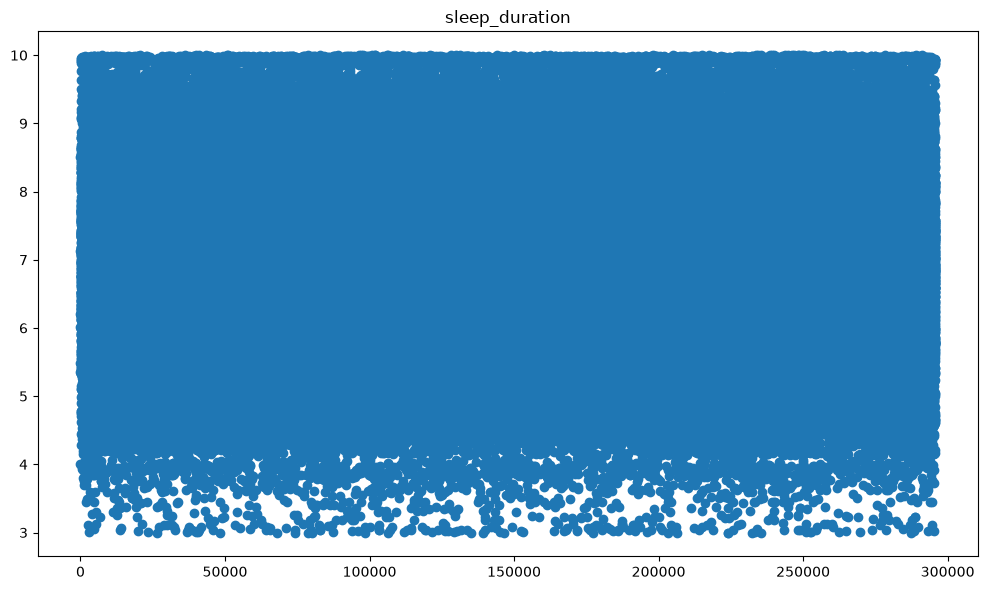

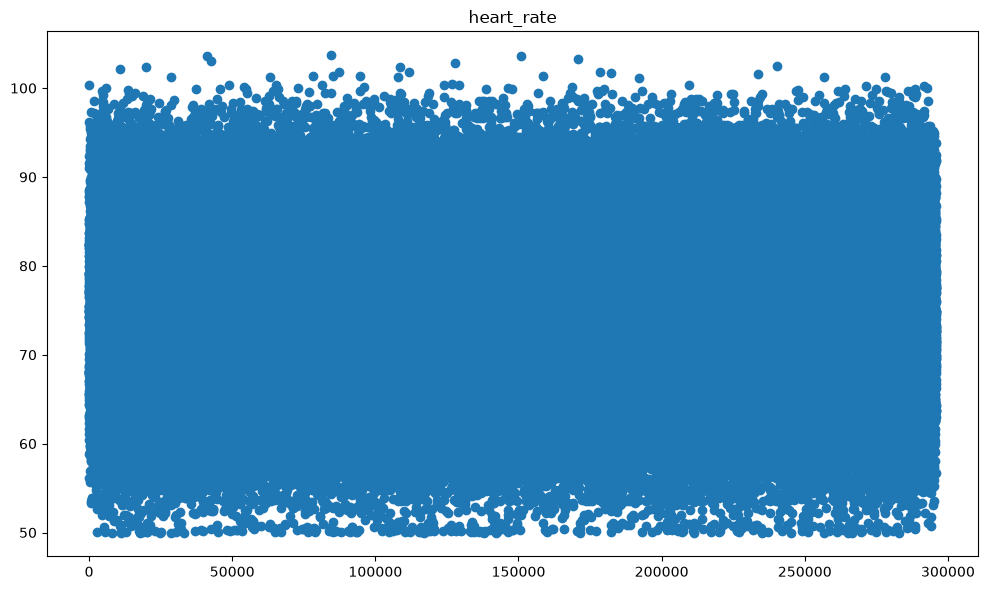

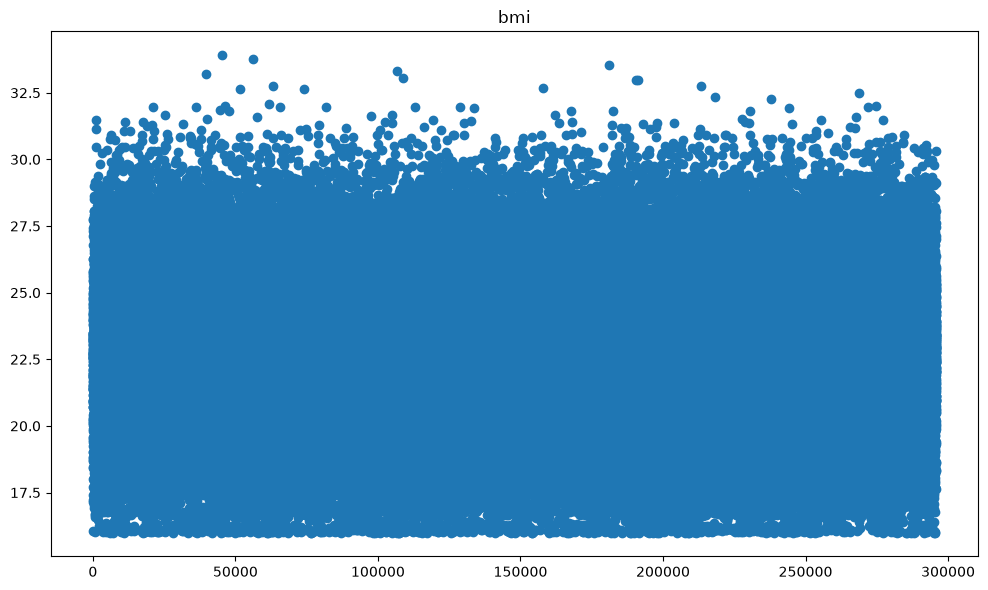

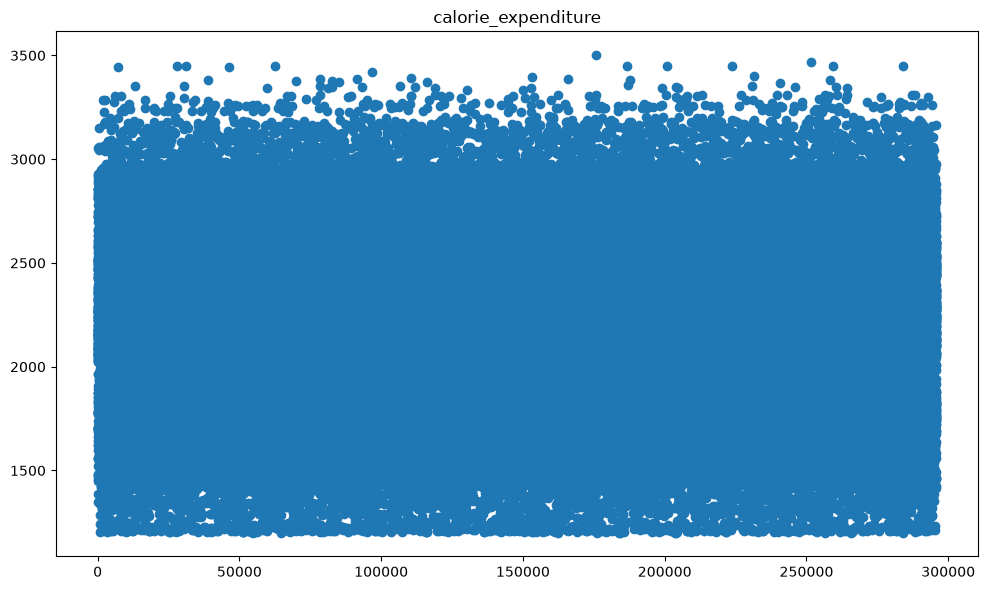

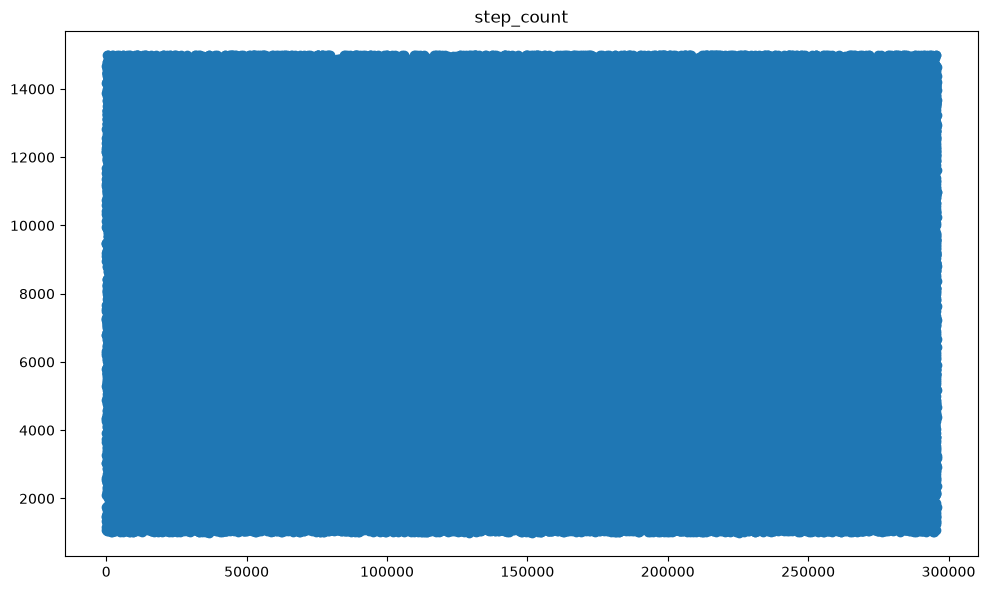

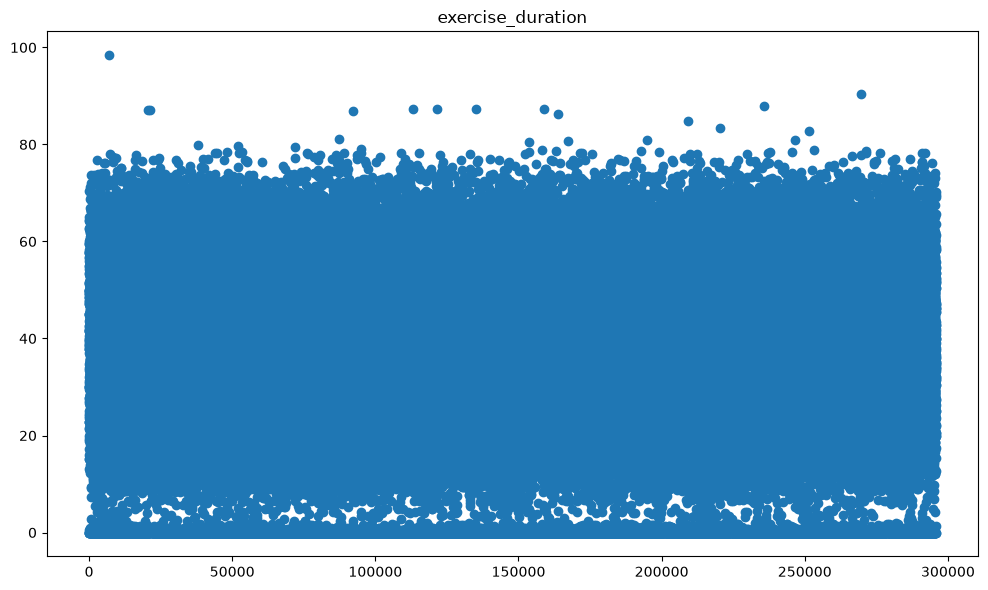

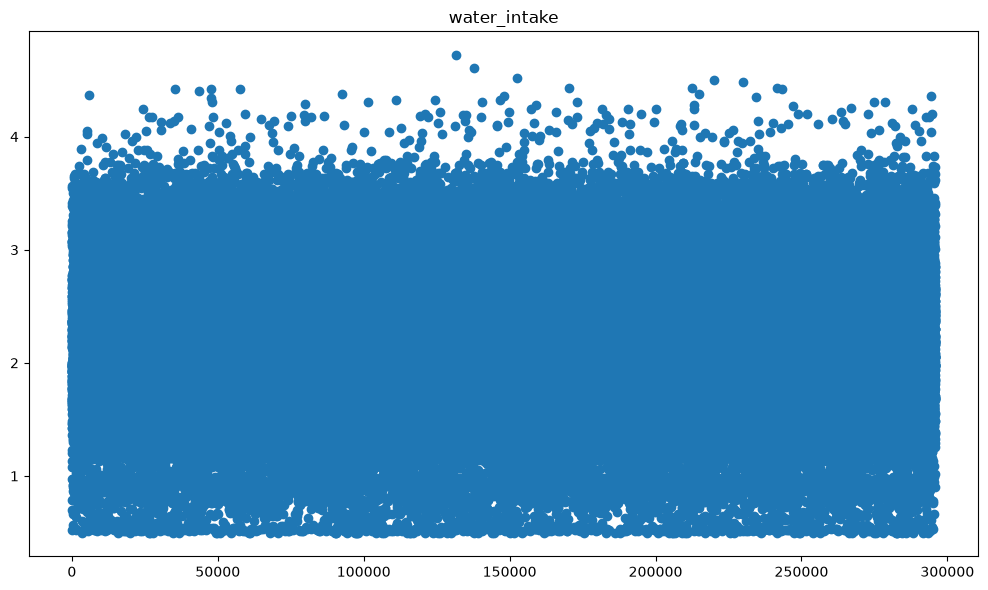

In [118]:
# Creating scatterplot

for col in num_data:
    plt.figure(figsize=(10, 6))
    plt.scatter(y=num_data[col], x=num_data.index)
    plt.title(f"{col}")
    plt.tight_layout()
    plt.show()

In [119]:

def outlier_remover(df, threshold:int):
    '''
    This calculates the stats of the data and remove the oulier
    using 3 standard deviation above and below the mean of the data
    '''
    data_outlier = {}
    data_stats = {}
    all_outlier_row = set()
    for col in df:
        
        ## Calculating the stats
        data_mean = df[col].mean()
        data_std = df[col].std()
        
        data_stats[col] = float(data_mean), float(data_std)
        
        ## Calculating outlier threasold
        outlier_threasold = data_std * threshold
        
        ## Calculating the limit
        upper_limit = data_mean + outlier_threasold
        lower_limit = data_mean - outlier_threasold
        
        is_outlier = (df[col] < lower_limit) | (df[col] > upper_limit)
        outlier_row = df[is_outlier].index
        
        data_outlier[col] = float(is_outlier.sum())
        
        print("-------------------------------")
        print(outlier_row)
        
        all_outlier_row.update(outlier_row)
        
    ## Cleaning the dataset
    cleaned_data = df.drop(index=all_outlier_row)
    
    return cleaned_data, data_stats, data_outlier

In [120]:
cleaned_data, outlier_data, is_outlier =  outlier_remover(num_data, 2.5)
outlier_data

-------------------------------
Index([    10,    191,    409,    481,    547,    708,    719,    722,    723,
          925,
       ...
       294426, 294434, 294557, 294654, 294664, 294676, 294853, 295134, 295171,
       295348],
      dtype='int64', length=2588)
-------------------------------
Index([    44,    149,    343,    352,    514,    554,    836,   1039,   1051,
         1171,
       ...
       293011, 293170, 293208, 293372, 293677, 294047, 294131, 294230, 294896,
       294998],
      dtype='int64', length=2033)
-------------------------------
Index([   210,    564,    637,    664,    722,    899,    915,    969,   1038,
         1057,
       ...
       295012, 295062, 295151, 295235, 295330, 295376, 295474, 295585, 295637,
       295669],
      dtype='int64', length=2920)
-------------------------------
Index([   159,    342,    708,    727,    831,    932,   1331,   1447,   1648,
         1723,
       ...
       294155, 294276, 294316, 294407, 294424, 294429, 294469, 29

{'sleep_duration': (6.998930909981899, 1.1829174777476579),
 'heart_rate': (75.08648519194745, 8.103898405549002),
 'bmi': (22.858679534299196, 2.400553508152626),
 'calorie_expenditure': (2219.7112939558483, 347.258265235083),
 'step_count': (8526.765048727859, 3893.8638480882014),
 'exercise_duration': (38.62660801934887, 14.695834430452145),
 'water_intake': (2.190787043843217, 0.5182573649149822)}

In [121]:
is_outlier

{'sleep_duration': 2588.0,
 'heart_rate': 2033.0,
 'bmi': 2920.0,
 'calorie_expenditure': 2561.0,
 'step_count': 0.0,
 'exercise_duration': 6870.0,
 'water_intake': 4074.0}

In [122]:
cleaned_data

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
0,5.350,64.9,23.48,2745.0,14167.0,59.5,1.86
1,6.015,83.1,22.42,1773.0,6801.0,24.5,2.40
3,7.130,78.5,26.26,2494.0,6331.0,56.9,2.34
4,5.490,77.7,23.29,1828.0,13894.0,39.4,2.45
5,8.510,72.0,21.96,2449.0,7232.0,49.9,2.56
...,...,...,...,...,...,...,...
295748,7.130,77.5,22.20,2221.0,13981.0,65.6,2.17
295749,6.250,69.5,20.93,2242.0,2370.0,23.6,1.98
295750,6.750,77.0,23.62,2111.0,7647.0,25.1,2.18
295751,7.250,66.3,21.47,2009.0,4672.0,25.1,2.02


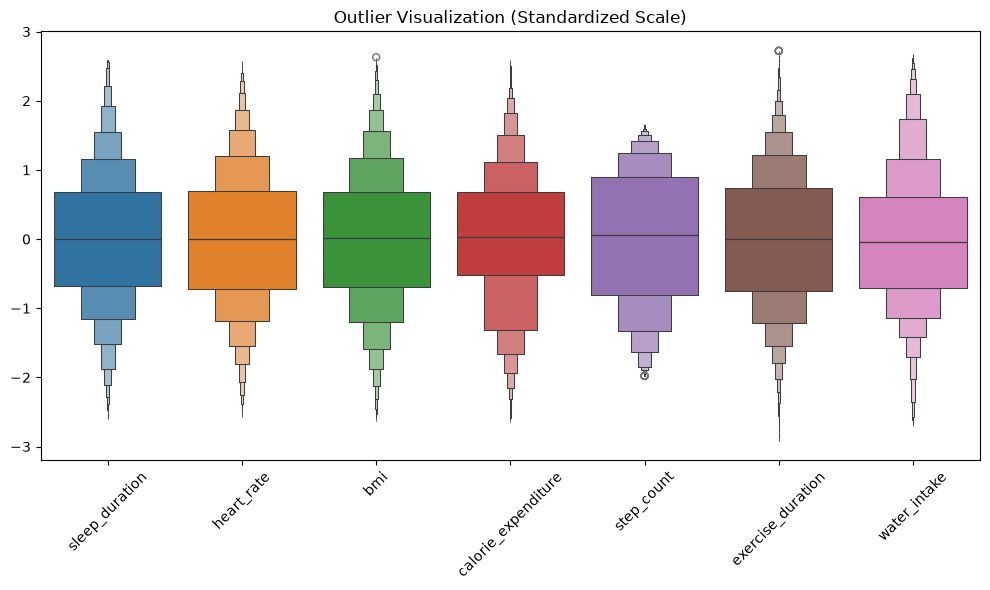

In [123]:
## Checking if outliers are gone 

## Standardizing data
standardized_cleaned_data = (cleaned_data - cleaned_data.mean()) / cleaned_data.std()

plt.figure(figsize=(10, 6))
sns.boxenplot(data=standardized_cleaned_data.dropna())
plt.title("Outlier Visualization (Standardized Scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [124]:
# Check how many outliers remain
standardized = (cleaned_data - cleaned_data.mean()) / cleaned_data.std()
beyond_3std = (standardized.abs() > 3).sum()
print(beyond_3std)


sleep_duration         0
heart_rate             0
bmi                    0
calorie_expenditure    0
step_count             0
exercise_duration      0
water_intake           0
dtype: int64


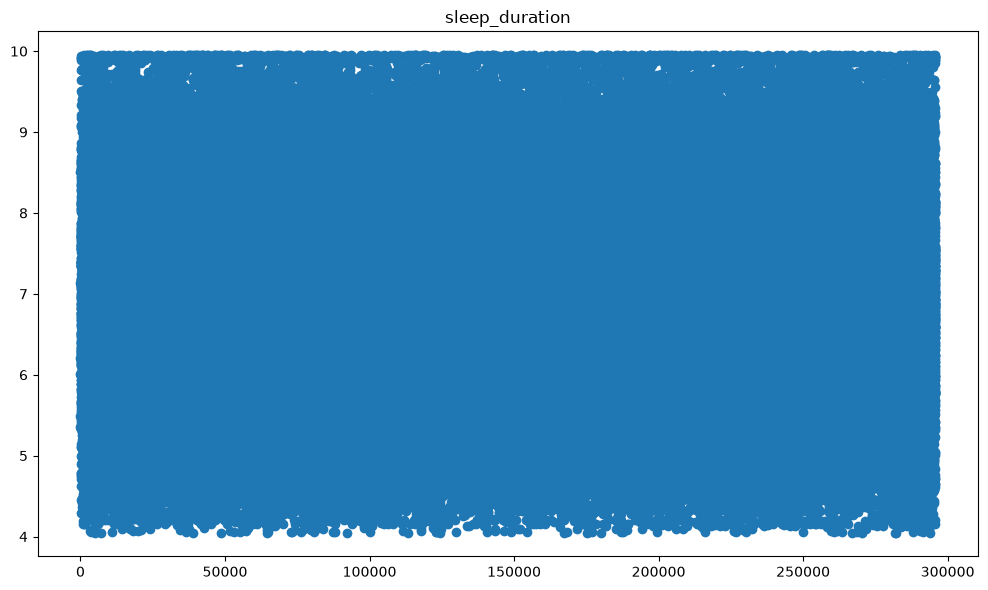

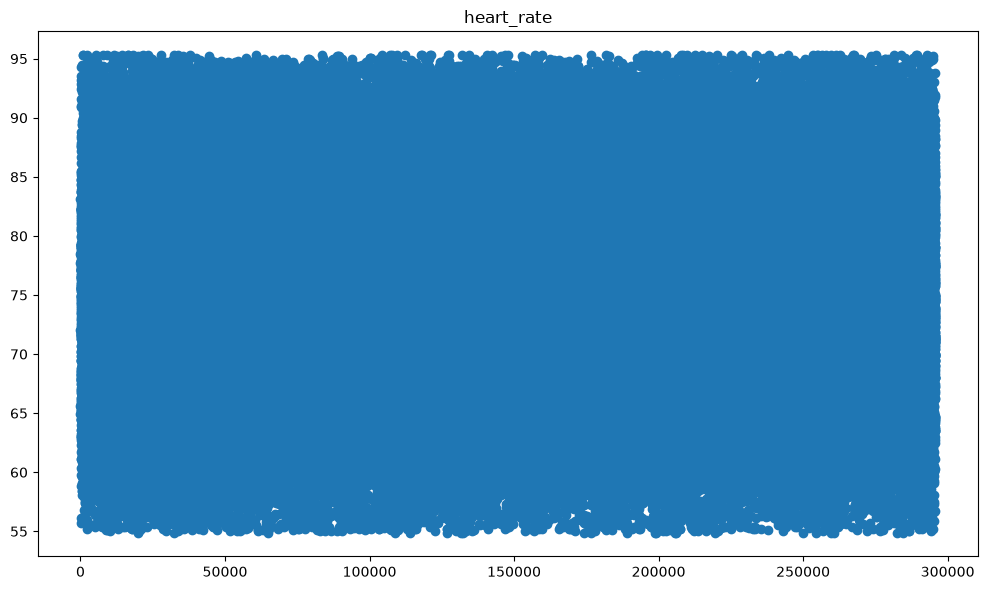

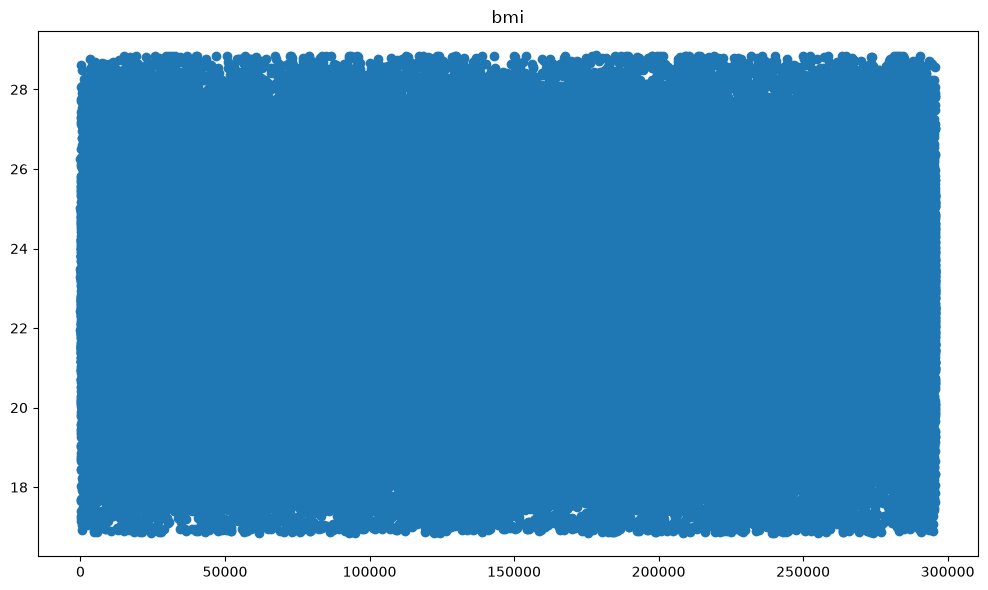

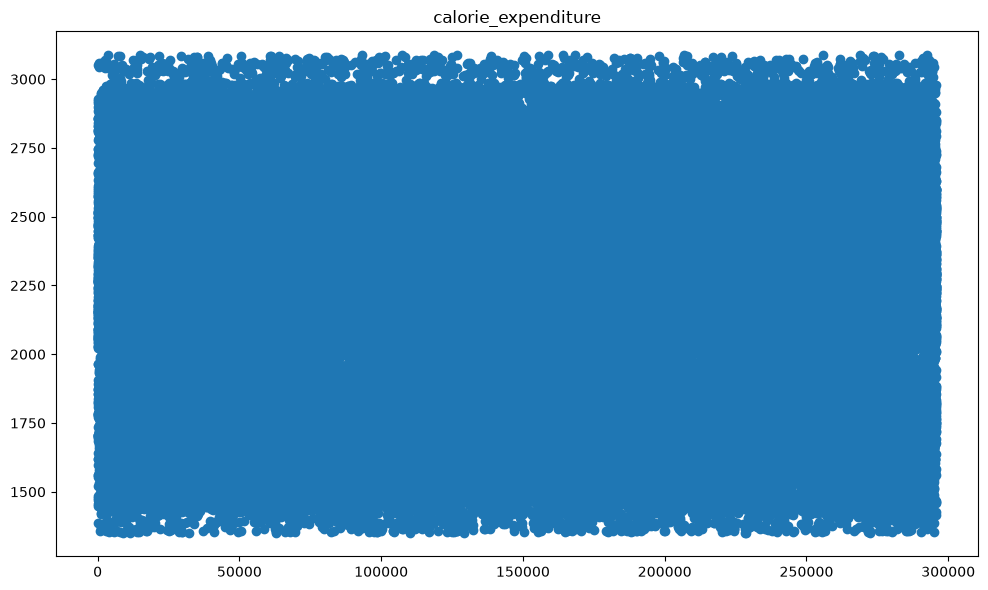

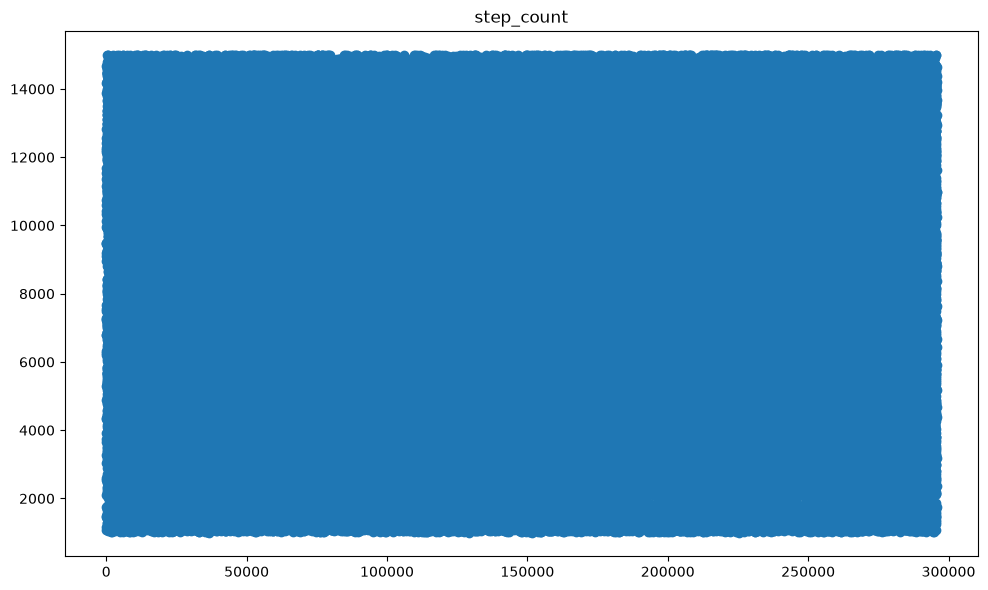

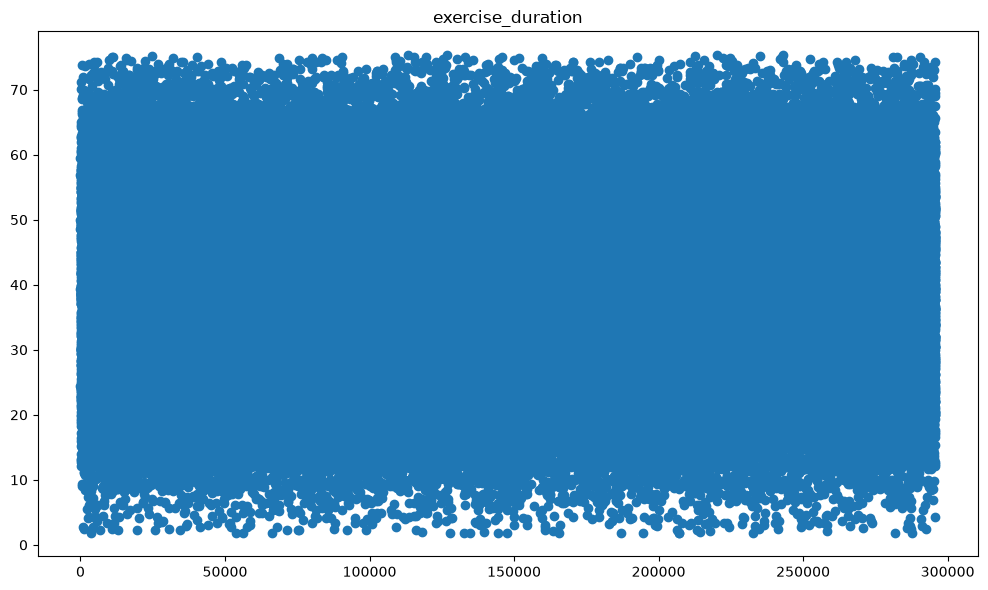

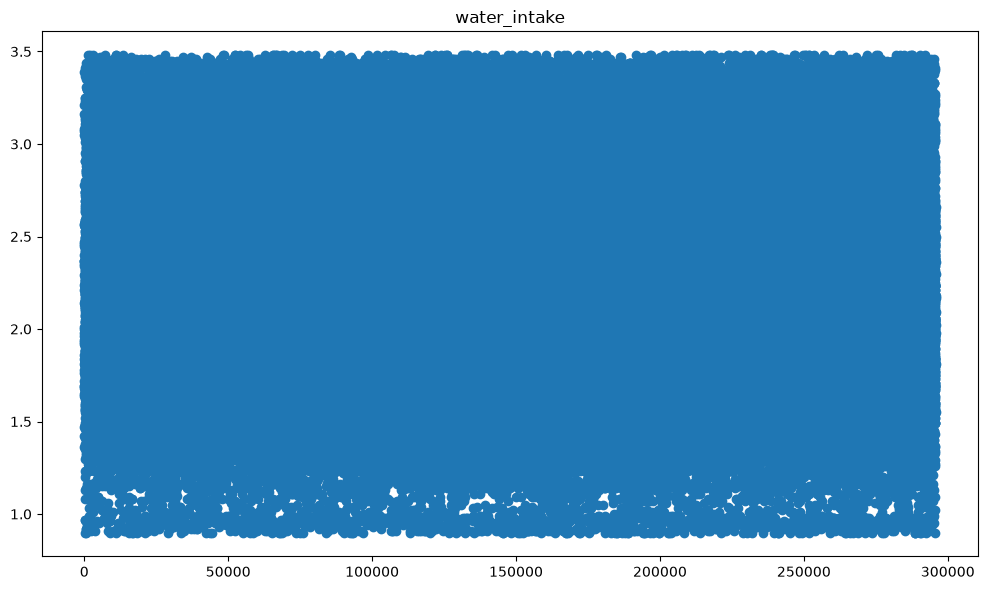

In [125]:

for col in cleaned_data:
    plt.figure(figsize=(10, 6))
    plt.scatter(x=cleaned_data.index, y=cleaned_data[col])
    plt.title(f"{col}")
    plt.tight_layout()
    plt.show()

In [126]:
# Check final row/column dimensions
print("Dataset Dimensions:", cleaned_data.shape)

Dataset Dimensions: (190791, 7)


In [127]:
# Check for missing values and structural types
cleaned_data.info()

<class 'pandas.DataFrame'>
Index: 190791 entries, 0 to 295752
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   sleep_duration       190791 non-null  float64
 1   heart_rate           190791 non-null  float64
 2   bmi                  190791 non-null  float64
 3   calorie_expenditure  190791 non-null  float64
 4   step_count           190791 non-null  float64
 5   exercise_duration    190791 non-null  float64
 6   water_intake         190791 non-null  float64
dtypes: float64(7)
memory usage: 11.6 MB


In [128]:
print(f"Dataset before removing null values: {df.shape}")
print(f"Dataset after removing null values: {student_data.shape}")
print(f"Dataset after removing null values on numerical data: {cleaned_data.shape}")

Dataset before removing null values: (295753, 14)
Dataset after removing null values: (210865, 13)
Dataset after removing null values on numerical data: (190791, 7)


In [129]:
print((cleaned_data.shape[0] / student_data.shape[0]) * 100 )
print((student_data.shape[0]- cleaned_data.shape[0]) * 100 )
print("-------------percentgage reduction in data-----------")
print(f'the percentage reduction in dataset size is: {(( student_data.shape[0]- cleaned_data.shape[0]) / student_data.shape[0]) * 100}')

90.48016503450074
2007400
-------------percentgage reduction in data-----------
the percentage reduction in dataset size is: 9.519834965499253


In [139]:
# Filter the original dataset using the clean data's index
final_data = student_data.loc[cleaned_data.index]

# Verify that all columns (text + numbers) are back together
print("Dimensions:", final_data.shape)
print("Columns:", final_data.columns.tolist())


Dimensions: (190791, 13)
Columns: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


### Exploratory Data Analysis

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('data/train.csv')

print('=== SHAPE ===')
print(train.shape)

print('\n=== DTYPES ===')
print(train.dtypes)

print('\n=== FIRST 5 ROWS ===')
print(train.head())

print('\n=== TARGET DISTRIBUTION ===')
print(train['health_condition'].value_counts())
print(train['health_condition'].value_counts(normalize=True).round(3) * 100)

print('\n=== MISSING VALUES ===')
print(train.isnull().sum())

print('\n=== BASIC STATS ===')
print(train.describe().round(2))

=== SHAPE ===
(690088, 15)

=== DTYPES ===
id                           int64
health_condition               str
sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                 float64
exercise_duration          float64
water_intake               float64
diet_type                      str
stress_level                   str
sleep_quality                  str
physical_activity_level        str
smoking_alcohol                str
gender                         str
dtype: object

=== FIRST 5 ROWS ===
   id health_condition  sleep_duration  heart_rate    bmi  \
0   0        unhealthy            5.22        70.6  25.66   
1   1          at-risk            5.53        71.3  25.84   
2   2        unhealthy            5.29        75.4  24.54   
3   3        unhealthy            4.70        77.2  23.13   
4   4          at-risk            7.23        73.4  28.44   

   calorie_expenditure  step_

In [146]:
# Target distribution
print(train['health_condition'].value_counts())
print(train['health_condition'].value_counts(normalize=True).round(3) * 100)

# Missing values
print(train.isnull().sum())

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64
health_condition
at-risk      85.9
unhealthy     8.4
fit           5.8
Name: proportion, dtype: float64
id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64
